In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/weather-type-classification")

print("Path to dataset files:", path)

c:\Users\yamaw\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 186k/186k [00:00<00:00, 550kB/s]

Extracting files...
Path to dataset files: C:\Users\yamaw\.cache\kagglehub\datasets\nikhil7280\weather-type-classification\versions\1


In [2]:
import pandas as pd
import os

csv_file = os.path.join(path, "weather_classification_data.csv")

# 読み込み
df = pd.read_csv(csv_file)

df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [3]:
# 数値データの基本統計量を表示
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [5]:
df["Weather Type"].value_counts()

Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

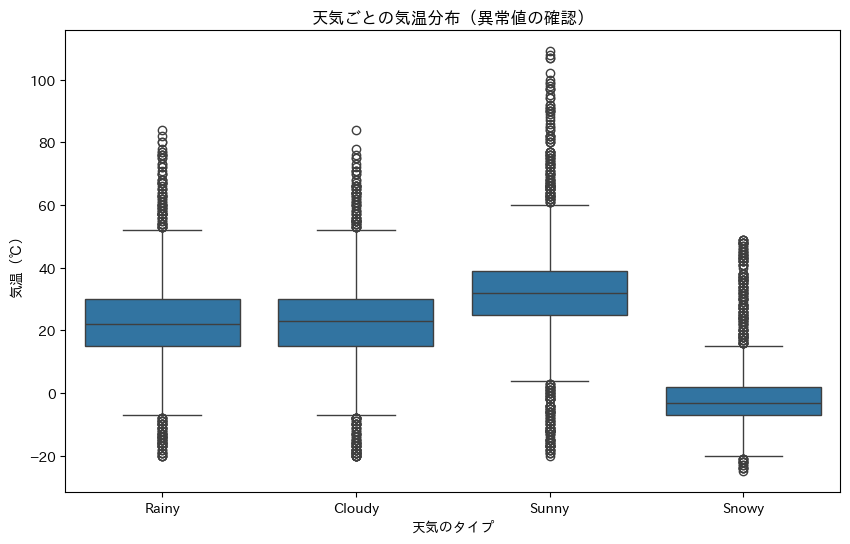

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib

# 気温の分布を箱ひげ図で表示
plt.figure(figsize=(10, 6))
sns.boxplot(x="Weather Type", y="Temperature", data=df)
plt.title("天気ごとの気温分布（異常値の確認）")
plt.xlabel("天気のタイプ")
plt.ylabel("気温（℃）")

plt.show()

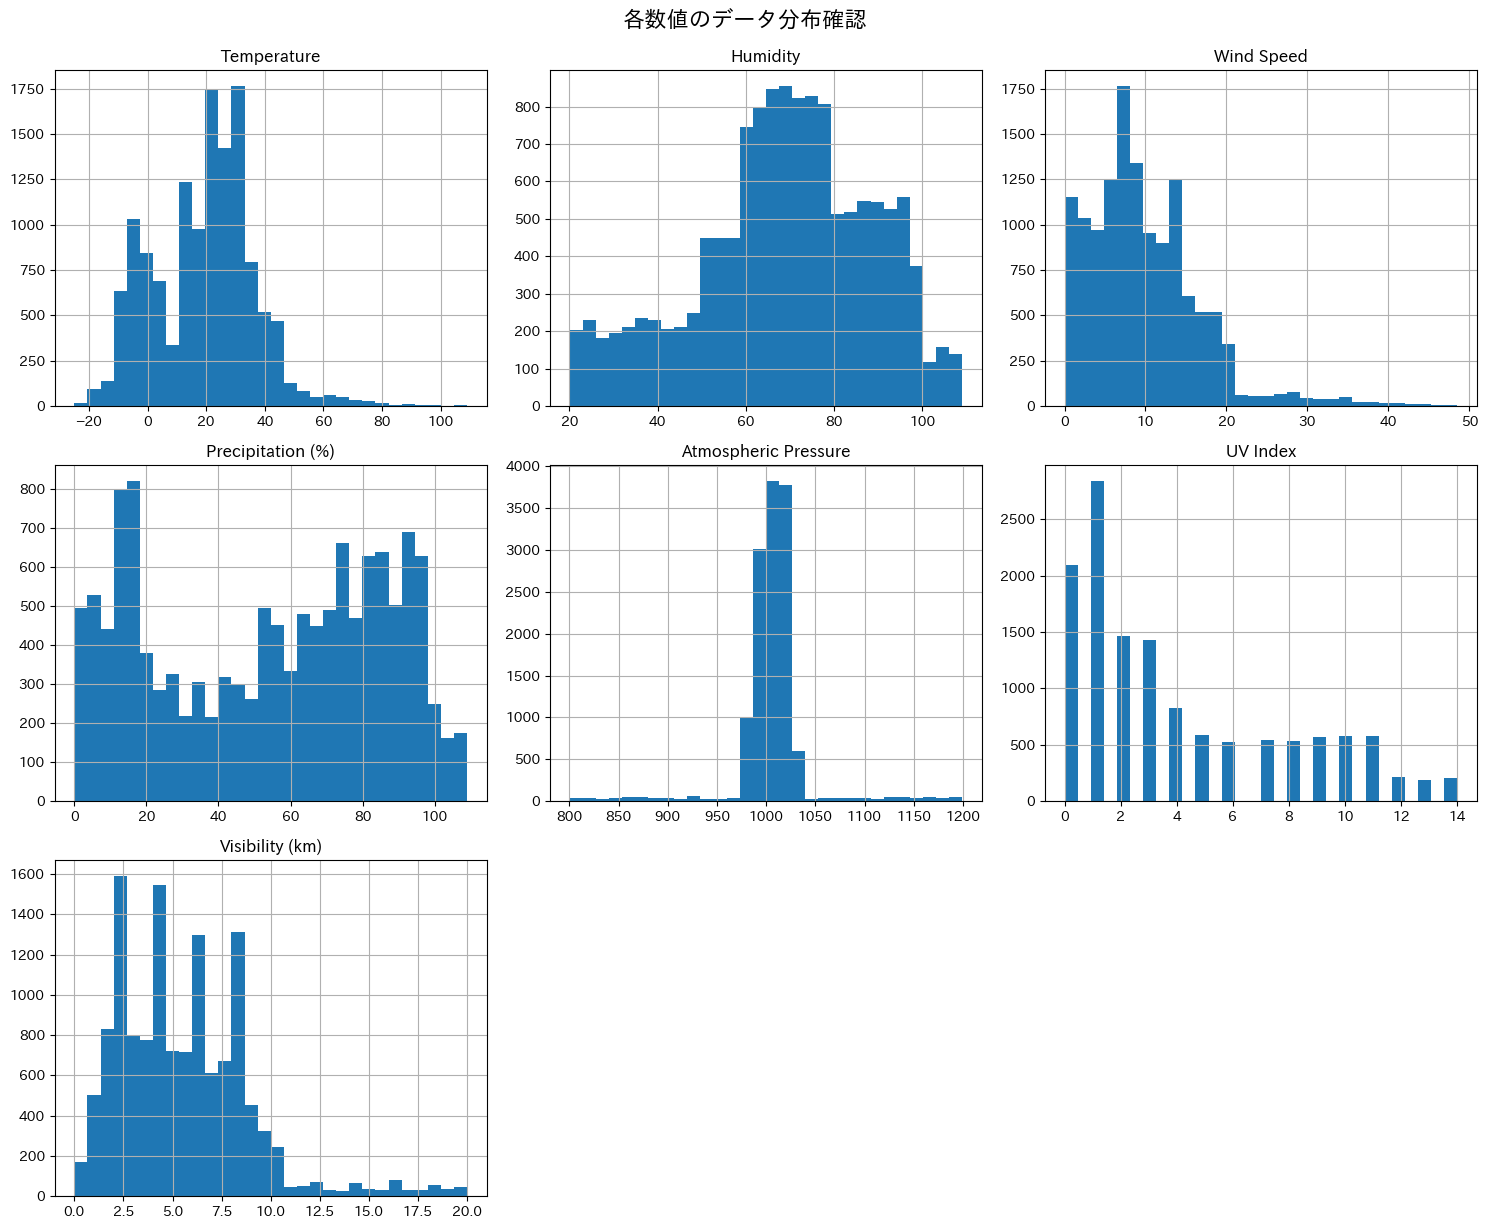

In [9]:
import matplotlib.pyplot as plt
import japanize_matplotlib

# 数値データのカラムだけを自動で選んで、ヒストグラムを作成
df.hist(figsize=(15, 12), bins=30)

# グラフ同士が重ならないように調整
plt.tight_layout()
plt.suptitle("各数値のデータ分布確認", y=1.02, fontsize=16)
plt.show()

In [11]:
# 数値カラムだけを抽出
numeric_cols = df.select_dtypes(include=["number"]).columns

# IQR方で外れ値を除外する処理
df_clean = df.copy()

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 範囲内のデータだけを残す
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]


# 結果の確認
print(f"元のデータ件数：{len(df)}件")
print(f"掃除後のデータ件数：{len(df_clean)}件")
print(f"消されたデータ件数：{len(df) - len(df_clean)}件")

元のデータ件数：13200件
掃除後のデータ件数：11586件
消されたデータ件数：1614件


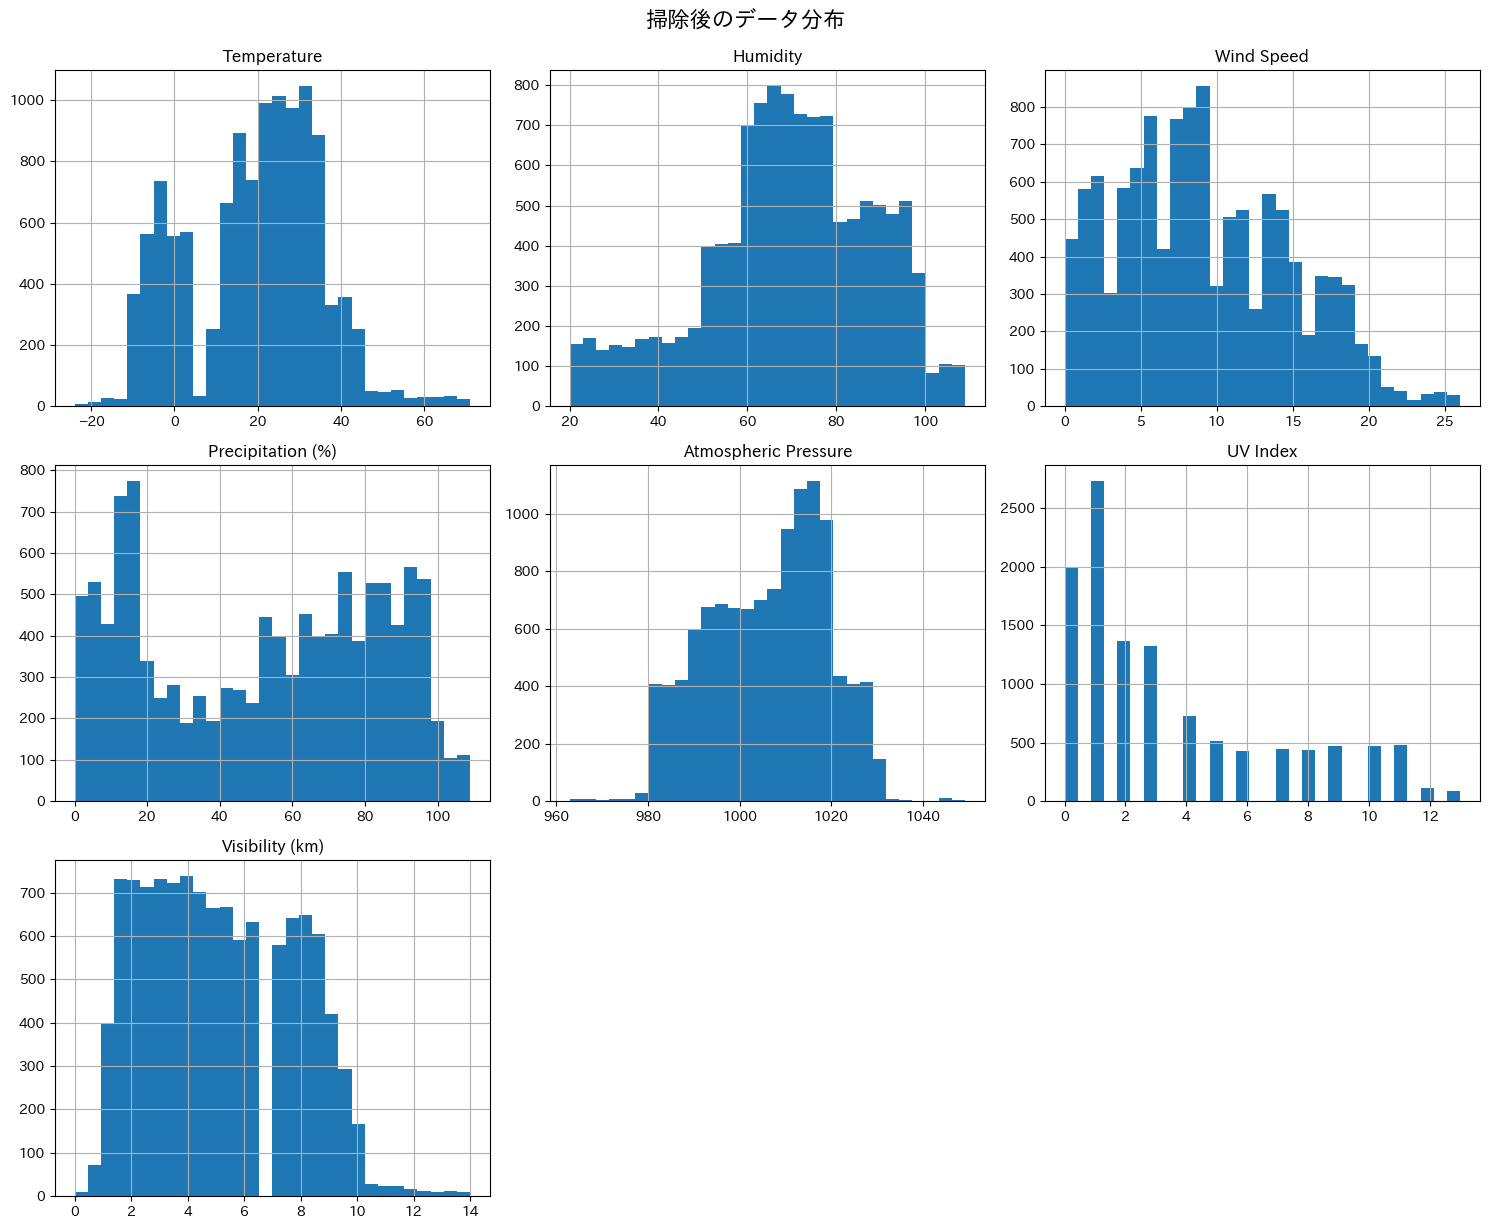

In [12]:
# 新しく作った「df_clean」でヒストグラムを表示してみる
df_clean.hist(figsize=(15, 12), bins=30)

plt.tight_layout()
plt.suptitle("掃除後のデータ分布", y=1.02, fontsize=16)
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

# カテゴリデータ（文字）のカラムを指定
categorical_cols = ["Cloud Cover", "Season", "Location", "Weather Type"]

# 掃除後のデータ（df_clean）をコピーして使う
df_encoded = df_clean.copy()

le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_clean[col])


# 結果を確認
df_encoded.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,1
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,0
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,3
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,3
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,1


In [18]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 特徴量（Ｘ）とターゲット（ｙ）に分ける
X = df_encoded.drop("Weather Type", axis=1)
y = df_encoded["Weather Type"]

# データを学習用（80%）とテスト用（20%）に分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# モデル（AI）を作って学習させる
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 予測
y_pred = model.predict(X_test)

# 正解率
print("--- ランダムフォレスト ---")
print(f"モデルの精度：{accuracy_score(y_test, y_pred):.2%}")

--- ランダムフォレスト ---
モデルの精度：97.58%


In [19]:
from sklearn.metrics import classification_report
import pandas as pd

# 評価レポートを作成
report_dict = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report_dict)

display(report_df)

,0,1,2,3,accuracy,macro avg,weighted avg
precision,0.942215,0.978799,0.992565,0.993232,0.975841,0.976703,0.976361
recall,0.983250,0.965157,0.978022,0.976705,0.975841,0.975783,0.975841
f1-score,0.962295,0.971930,0.985240,0.984899,0.975841,0.976091,0.975946
support,597.000000,574.000000,546.000000,601.000000,0.975841,2318.000000,2318.000000


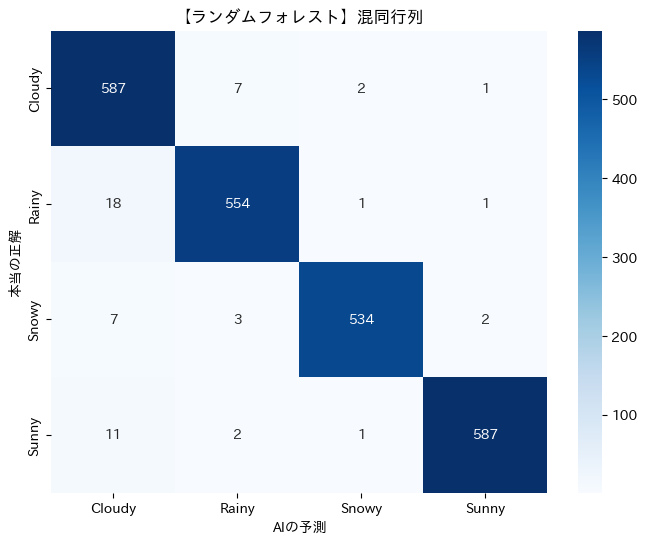

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 混同行列を作成
cm = confusion_matrix(y_test, y_pred)

# 可視化
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_, yticklabels=le.classes_
)

plt.title("【ランダムフォレスト】混同行列")
plt.xlabel("AIの予測")
plt.ylabel("本当の正解")
plt.show()

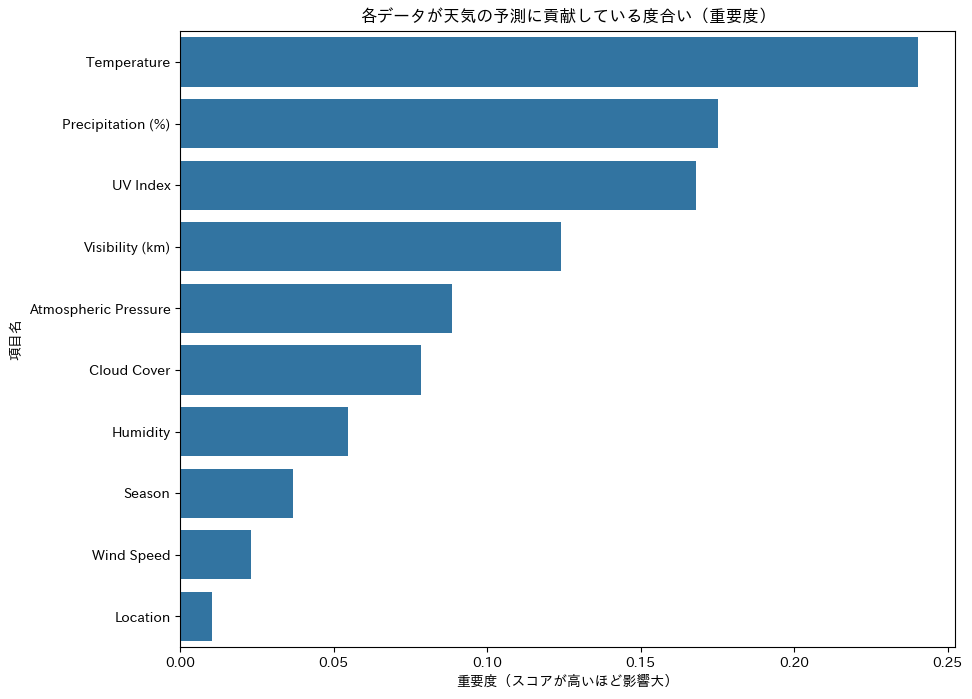

In [21]:
# モデルから重要度を取り出してシリーズにする
importances = pd.Series( model.feature_importances_,index=X.columns).sort_values(ascending=False)

# グラフの作成
plt.figure(figsize=(10, 8))
sns.barplot(x=importances, y=importances.index)

plt.title("各データが天気の予測に貢献している度合い（重要度）")
plt.xlabel("重要度（スコアが高いほど影響大）")
plt.ylabel("項目名")
plt.show()